Loading and preprocessing training images...


Processing meningioma: 100%|██████████| 1339/1339 [00:01<00:00, 1014.83it/s]



Loading and preprocessing test images...


Processing meningioma: 100%|██████████| 306/306 [00:00<00:00, 909.16it/s] 



Saving processed data...

Plotting sample images...


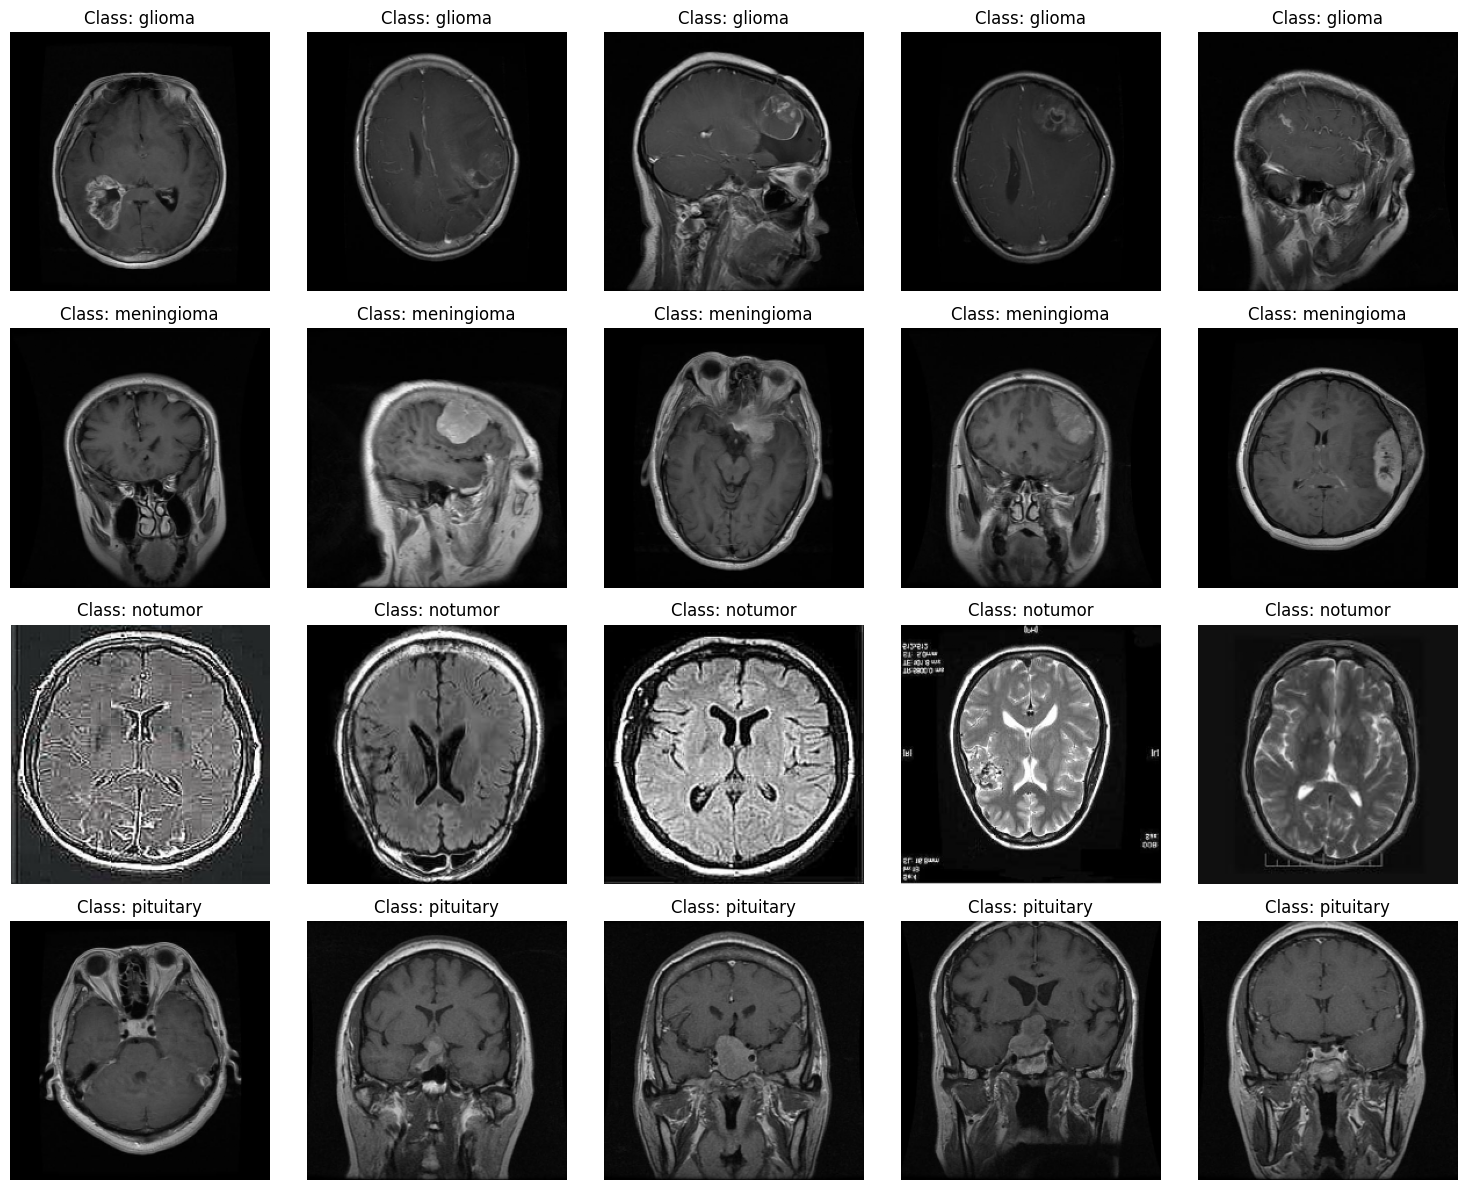


Preprocessing completed!
Training set shape: (5712, 224, 224, 3)
Test set shape: (1311, 224, 224, 3)


In [4]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Function to load and preprocess a single image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    """Load and preprocess a single image"""
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Resize
    img = cv2.resize(img, target_size)
    
    # Normalize
    img = img.astype(np.float32) / 255.0
    
    return img

# Function to create dataset from directory
def create_dataset(data_dir, target_size=(224, 224)):
    """Create dataset from directory structure"""
    images = []
    labels = []
    
    # Assuming directory structure: data_dir/class_name/image_files
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
            
        for img_name in tqdm(os.listdir(class_dir), desc=f'Processing {class_name}'):
            img_path = os.path.join(class_dir, img_name)
            img = load_and_preprocess_image(img_path, target_size)
            
            if img is not None:
                images.append(img)
                labels.append(class_name)
    
    return np.array(images), np.array(labels)

# Function for data augmentation
def augment_image(image):
    """Apply data augmentation to a single image"""
    augmented = []
    
    # Original image
    augmented.append(image)
    
    # Horizontal flip
    augmented.append(cv2.flip(image, 1))
    
    # Vertical flip
    augmented.append(cv2.flip(image, 0))
    
    # Rotate 90 degrees
    augmented.append(cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE))
    
    return augmented

# Set paths
RAW_DATA_DIR = '../data/raw/train'
RAW_DATA_DIR_TEST = '../data/raw/test'
PROCESSED_DATA_DIR = '../data/processed'

# Create processed data directory if it doesn't exist
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)


# Load and preprocess training data
print("Loading and preprocessing training images...")
X_train, y_train = create_dataset(os.path.join(RAW_DATA_DIR))

# Load and preprocess test data
print("\nLoading and preprocessing test images...")
X_test, y_test = create_dataset(os.path.join(RAW_DATA_DIR_TEST))

# Save processed data
print("\nSaving processed data...")
np.save(os.path.join(PROCESSED_DATA_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(PROCESSED_DATA_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(PROCESSED_DATA_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DATA_DIR, 'y_test.npy'), y_test)

# Function to plot sample images
def plot_sample_images(images, labels, num_samples=5):
    """Plot sample images from each class"""
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels), num_samples, figsize=(15, 3*len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        indices = np.where(labels == label)[0][:num_samples]
        for j, idx in enumerate(indices):
            axes[i, j].imshow(images[idx])
            axes[i, j].set_title(f'Class: {label}')
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot sample images
print("\nPlotting sample images...")
plot_sample_images(X_train, y_train)

# Print final information
print("\nPreprocessing completed!")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")